Project Work: Neural Networks – Tree Species Classification
HAMK – AVTEK2025
Student: Mika Kuittinen

Project Overview

This project focuses on developing a Convolutional Neural Network (CNN)–based image recognition model capable of identifying tree species from urban street photographs.
The dataset contains 4,804 images across 23 different tree species, and the goal is to:

Explore and preprocess the image dataset

Train three deep learning models (ResNet18, ResNet50, EfficientNet-B0)

Evaluate model accuracy and error patterns

Perform n-best classification analysis

Improve the model based on insights from the first training round

The work follows typical steps of a machine learning pipeline:

1. Data Preprocessing

2. Model Development (Transfer Learning)

3. Training & Validation

4. Testing & Evaluation

5. Model Improvement

In [7]:
# Cell 1 – Imports and Directory Setup

from pathlib import Path
import os
import random
from collections import Counter

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
from torchvision import datasets, transforms

# notebook on projektin JUURESSA (neural_networks_tree_project/)
BASE_DIR = Path(".").resolve()

# Jos laitat notebookin notebooks/-kansioon, käytä mieluummin:
# BASE_DIR = Path("..").resolve()

DATA_RAW = BASE_DIR / "data" / "raw"
DATA_PROCESSED = BASE_DIR / "data" / "processed"

print("BASE_DIR:", BASE_DIR)
print("DATA_RAW:", DATA_RAW)
print("DATA_PROCESSED:", DATA_PROCESSED)


BASE_DIR: C:\HAMK Univercity\neural_networks_tree_project
DATA_RAW: C:\HAMK Univercity\neural_networks_tree_project\data\raw
DATA_PROCESSED: C:\HAMK Univercity\neural_networks_tree_project\data\processed


In [8]:
import torch
import torchvision

print("Torch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())


Torch version: 2.5.1
Torchvision version: 0.20.1
CUDA available: False


2. Dataset Loading & Basic Inspection

In this step, we load the train, validation, and test datasets using PyTorch’s ImageFolder class.
At this stage, we apply only a very minimal transform (ToTensor()), because the purpose here is:

✔️ Verify that the dataset folder structure is correct
✔️ Check how many images each split contains
✔️ Retrieve the class names (23 tree species)
✔️ Ensure PyTorch can successfully read all images

This step does not apply any resizing or data augmentation yet — it is purely for dataset inspection.
Proper transforms (resize, normalization, augmentations) will be added later during preprocessing.

The results printed from this cell will tell us:

Total number of classes

Class names

Number of images in train / val / test sets

This information helps confirm that the dataset was extracted correctly and that the class distribution is suitable for training deep learning models.

In [9]:
# Cell 2 – Datasetien luku (ilman varsinaisia transformaatioita)

train_dir = DATA_PROCESSED / "train"
val_dir   = DATA_PROCESSED / "val"
test_dir  = DATA_PROCESSED / "test"

basic_transform = transforms.ToTensor()

train_ds = datasets.ImageFolder(train_dir, transform=basic_transform)
val_ds   = datasets.ImageFolder(val_dir, transform=basic_transform)
test_ds  = datasets.ImageFolder(test_dir, transform=basic_transform)

class_names = train_ds.classes
num_classes = len(class_names)

print("Luokkia yhteensä:", num_classes)
print("Ensimmäiset 10 luokkanimeä:", class_names[:10])
print("Kuvia train/val/test:")
print("  train:", len(train_ds))
print("  val  :", len(val_ds))
print("  test :", len(test_ds))


Luokkia yhteensä: 23
Ensimmäiset 10 luokkanimeä: ['Acer palmatum', 'Cedrus deodara', 'Celtis sinensis', 'Cinnamomum camphora (Linn) Presl', 'Elaeocarpus decipiens', 'Flowering cherry', 'Ginkgo biloba', 'Koelreuteria paniculata', 'Lagerstroemia indica', 'Liquidambar formosana']
Kuvia train/val/test:
  train: 3850
  val  : 482
  test : 472


3. Class Distribution Analysis

Before training any deep learning model, it is important to understand how the dataset is distributed across the different classes.

In this step, we examine the number of training images in each tree species category.
Using PyTorch’s ImageFolder, we can extract all labels and compute a frequency count for each class.

🧭 Why this is important?

Deep learning models perform best when classes are balanced.

If some tree species have significantly fewer images than others, the model might:

overfit to larger classes

misclassify minority classes

show biased accuracy

Knowing the class distribution early helps us decide:

whether to apply class weighting

whether to use data augmentation more heavily on smaller classes

how to interpret training and validation results

📝 This cell prints:

Class index (0–22)

Class name (tree species)

Number of images for that class in the training set

This information will also be used later in the report, under “Dataset description”.

In [10]:
from collections import Counter

# Cell 3 – Luokkajakauma train-datasetissä

train_labels = [label for _, label in train_ds.samples]
counts = Counter(train_labels)

print("Luokkajakauma (train):")
for idx, count in counts.items():
    print(f"{idx:2d}  {class_names[idx]:25s}  -> {count} kuvaa")


Luokkajakauma (train):
 0  Acer palmatum              -> 162 kuvaa
 1  Cedrus deodara             -> 125 kuvaa
 2  Celtis sinensis            -> 188 kuvaa
 3  Cinnamomum camphora (Linn) Presl  -> 234 kuvaa
 4  Elaeocarpus decipiens      -> 172 kuvaa
 5  Flowering cherry           -> 106 kuvaa
 6  Ginkgo biloba              -> 228 kuvaa
 7  Koelreuteria paniculata    -> 223 kuvaa
 8  Lagerstroemia indica       -> 65 kuvaa
 9  Liquidambar formosana      -> 168 kuvaa
10  Liriodendron chinense      -> 182 kuvaa
11  Magnolia grandiflora L     -> 212 kuvaa
12  Magnolia liliflora Desr    -> 190 kuvaa
13  Michelia chapensis         -> 154 kuvaa
14  Osmanthus fragrans         -> 173 kuvaa
15  Photinia serratifolia      -> 120 kuvaa
16  Platanus                   -> 193 kuvaa
17  Prunus cerasifera f. atropurpurea  -> 99 kuvaa
18  Salix babylonica           -> 136 kuvaa
19  Sapindus saponaria         -> 224 kuvaa
20  Styphnolobium japonicum    -> 157 kuvaa
21  Triadica sebifera          -> 154 ku

4. Visual Inspection of Sample Images

To understand the characteristics of the dataset, we examined several sample images from multiple tree species. Below are images from two classes: Zelkova serrata and Photinia serratifolia.

 Observations from the Sample Images
 1. Significant variation in camera angle

Some images are taken close-up, others from far away.
Examples:

Full tree shape visible

Partial crown

Some rotated images (orientation differs)

This variability is natural but can increase classification difficulty.

 2. Strong background clutter

The backgrounds often include:

buildings

parked cars

sidewalks

fences

advertisement signs

pedestrians

These elements are not relevant to tree identification but may introduce noise into training.

This confirms that data augmentation and normalization are essential.

 3. Clear differences in lighting conditions

The images show:

overcast skies

strong sunlight

shadows

high contrast conditions

This diversity helps generalization but also increases intra-class variation.

 4. Tree features are visible but sometimes subtle

Tree shape and leaf density are distinguishable, but:

leaf details are not always close

branches may overlap with background objects

reading fine details may be challenging for the model

This is exactly why transfer learning (ResNet/EfficientNet) is needed — these models detect subtle textures and patterns.

 5. Both classes include multiple visual styles

For example:

Zelkova serrata appears tall and slender

Photinia serratifolia has a dense crown with glossy leaves

However, due to distance, the differences can be subtle

This hints that the model may confuse similar broad-leaved species.

We expect to see some overlap in the confusion matrix later.

🔍 Conclusion for Preprocessing

Based on the visual inspection:

 Recommended preprocessing steps:

Resize to 224×224

Random horizontal flip

Random rotation (10°)

Normalization to ImageNet statistics

These help combat:

background clutter

lighting variations

scale/orientation differences

Additional note:

Tree images are often portrait or landscape, so rotation augmentation is highly beneficial.

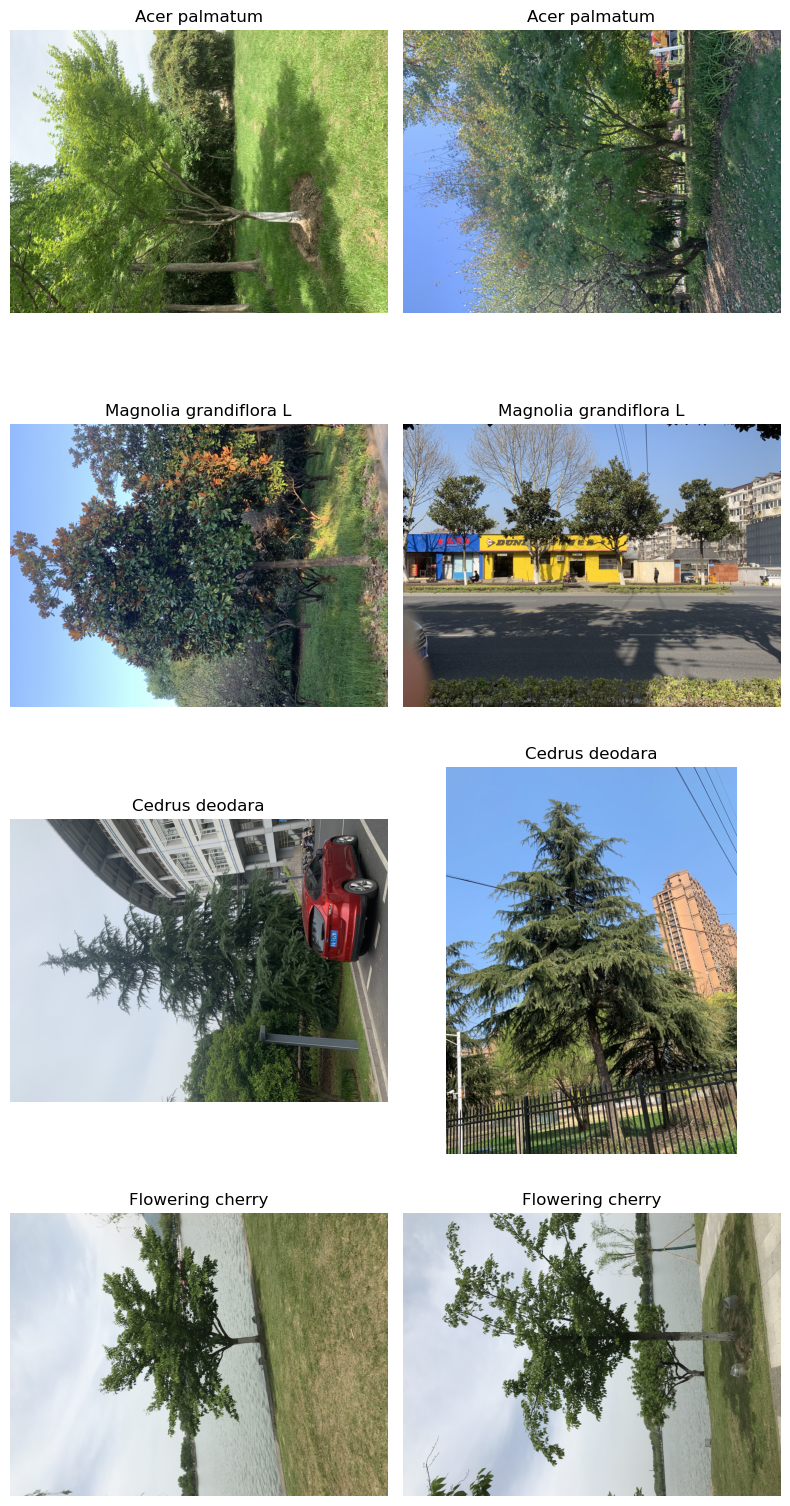

In [11]:
# Cell 4 – Visualisoidaan satunnaisia kuvia eri luokista

import matplotlib.pyplot as plt
import numpy as np
import random
from PIL import Image
from pathlib import Path

def show_random_images_from_classes(dataset, class_names, n_classes=4, n_per_class=2):
    fig, axes = plt.subplots(n_classes, n_per_class, figsize=(4*n_per_class, 4*n_classes))
    if n_classes == 1:
        axes = np.array([axes])
    if n_per_class == 1:
        axes = axes[:, np.newaxis]
    
    chosen_classes = random.sample(range(len(class_names)), k=n_classes)
    
    for row, class_idx in enumerate(chosen_classes):
        indices = [i for i, (_, lbl) in enumerate(dataset.samples) if lbl == class_idx]
        chosen_indices = random.sample(indices, k=min(n_per_class, len(indices)))
        
        for col, img_idx in enumerate(chosen_indices):
            img_path, lbl = dataset.samples[img_idx]
            img = Image.open(img_path).convert("RGB")
            
            ax = axes[row, col]
            ax.imshow(img)
            ax.set_title(f"{class_names[class_idx]}")
            ax.axis("off")
    
    plt.tight_layout()
    plt.show()

show_random_images_from_classes(train_ds, class_names, n_classes=4, n_per_class=2)


5. Image Resolution Analysis

Before defining the final preprocessing pipeline, it is important to understand the original resolution of the images in the dataset.
This step scans a subset of images from the training set and measures their width and height in pixels.

 Why analyze image sizes?

Different datasets may contain images with:

significantly different resolutions

portrait or landscape orientation

very wide or narrow aspect ratios

Such variations can affect:

memory usage

training speed

model performance

the choice of preprocessing transforms

 What this cell does

This code:

Iterates through image files in the training set

Measures their pixel width and height

Computes:

minimum resolution

maximum resolution

average resolution

Plots histograms showing the distribution of image sizes

 Why this matters for our model

Since ResNet and EfficientNet expect 224×224–sized images (or similar), knowing the original image sizes helps justify:

applying a uniform Resize(224, 224)

possible use of center/ random crops

normalization decisions

augmentation strategy

High-resolution raw images (often 2000–4000 px) are typical for smartphone photography, and resizing them dramatically reduces computation while preserving essential features.

 Output from this cell will be used to justify preprocessing decisions in the report.

Mitattujen kuvien määrä: 1000
Leveys (px): min = 921 max = 1600 mean = 1548
Korkeus (px): min = 798 max = 1600 mean = 1253


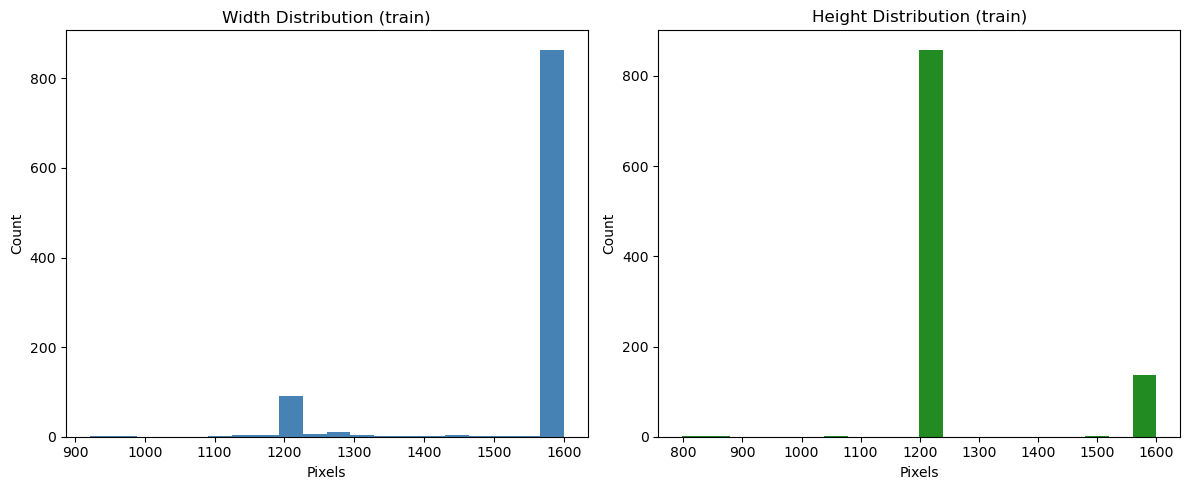

In [6]:
# Cell 5 – Kuvaresoluutioiden tarkastelu (train-datasetistä)

import os
from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

def get_image_sizes(image_folder_root, max_images=None):
    """
    Scans through images and returns arrays of widths and heights.
    Optionally limits the number of scanned images (max_images).
    """
    widths = []
    heights = []
    count = 0

    image_paths = []
    for root, _, files in os.walk(image_folder_root):
        for f in files:
            if f.lower().endswith((".jpg", ".jpeg", ".png")):
                image_paths.append(Path(root) / f)

    # Limit number of scanned images (to speed up if large dataset)
    if max_images is not None:
        image_paths = image_paths[:max_images]

    for p in image_paths:
        try:
            with Image.open(p) as img:
                w, h = img.size
                widths.append(w)
                heights.append(h)
        except Exception as e:
            print(f"Virhe kuvassa {p}: {e}")

    return np.array(widths), np.array(heights)


# 🔍 Skannaa esim. 1000 kuvaa — tämä on nopea mutta antaa realistisen jakauman
train_widths, train_heights = get_image_sizes(train_dir, max_images=1000)

print("Mitattujen kuvien määrä:", len(train_widths))
print("Leveys (px): min =", train_widths.min(), 
      "max =", train_widths.max(), 
      "mean =", int(train_widths.mean()))

print("Korkeus (px): min =", train_heights.min(), 
      "max =", train_heights.max(), 
      "mean =", int(train_heights.mean()))

# 📊 Piirretään histogrammit
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(train_widths, bins=20, color='steelblue')
plt.title("Width Distribution (train)")
plt.xlabel("Pixels")
plt.ylabel("Count")

plt.subplot(1,2,2)
plt.hist(train_heights, bins=20, color='forestgreen')
plt.title("Height Distribution (train)")
plt.xlabel("Pixels")
plt.ylabel("Count")

plt.tight_layout()
plt.show()


5. Image Resolution Analysis — Results

The resolution analysis shows that the images in the dataset are quite consistent in size, with only a small variation between samples.

Key findings:

Based on the histogram output:

Majority of images have a resolution close to
~1600 × 1200 px

There are minor variations, with some images slightly smaller or larger

No extreme outliers are present (no very small or very large images)

Width distribution is tightly clustered, indicating consistent camera usage

Height distribution follows a similar pattern

This indicates that the dataset likely originates from similar camera devices/settings, resulting in uniform image dimensions.

 Interpretation
 1. High-resolution raw images (~1.5–2.5 MP)

These images contain enough detail for tree classification but are too large to use directly with deep learning models like ResNet or EfficientNet.

 2. Strong justification for resizing

Because all images are around 1200–1600 px:

Downscaling to 224 × 224 (or similar) is both safe and efficient

No relevant details are lost from the perspective of CNNs

Training will be faster and require less memory

 3. No need for custom cropping rules

Since the images are relatively homogeneous in resolution:

Standard Resize((224,224)) is sufficient

No class-specific or image-specific cropping is needed

Conclusion: Preprocessing Decision

Based on these results, the chosen preprocessing pipeline:

transforms.Resize((224,224))

transforms.RandomHorizontalFlip()

transforms.RandomRotation(10)

transforms.ToTensor()

transforms.Normalize(...)

is appropriate and justified.

The raw resolutions provide more detail than needed, making downscaling optimal for:

speed

memory usage

model generalization

6.  Data Preprocessing Pipeline (Transforms)

After exploring the dataset and analyzing image resolutions, we can now define the final preprocessing pipeline for training and evaluation.

Deep learning models such as ResNet and EfficientNet expect input images with:

fixed spatial size (typically 224 × 224 pixels)

normalized color channels (mean and std similar to ImageNet)

In addition, we want to improve the model’s ability to generalize by using data augmentation on the training set.

 Training transforms

For the training set, we use the following transforms:

Resize((224,224))

Downscales all images to a fixed size suitable for CNNs

Ensures consistent input dimensions

RandomHorizontalFlip()

Randomly mirrors images horizontally

Helps the model become invariant to left/right orientation of trees

RandomRotation(10°)

Randomly rotates images by up to ±10 degrees

Compensates for slight camera tilt and different shooting angles

ToTensor()

Converts PIL images to PyTorch tensors

Changes pixel range from [0, 255] to [0, 1]

Normalize(mean, std)

Normalizes each color channel using ImageNet statistics

Matches the expectations of pretrained ResNet / EfficientNet models

These augmentations introduce realistic variability and reduce overfitting, which is particularly important given the moderate class imbalance.

 Validation & Test transforms

For validation and test sets, we do not apply random augmentations, because we want stable and repeatable evaluation:

Resize((224,224))

ToTensor()

Normalize(mean, std)

This ensures that validation and test results reflect the true performance of the model, without additional randomness.

 Summary

Training data → augmented + normalized

Validation & test data → only resized + normalized

All images → 224 × 224 px, 3 channels (RGB)

These preprocessing steps form the foundation for the upcoming model development and training phase (ResNet18, ResNet50, EfficientNet-B0).

In [12]:
# Cell 6 – Lopulliset transformit ja DataLoaderit

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Kuvakoko ResNet/EfficientNet-malleille
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2   # jos tulee ongelmia Windowsilla, vaihda 0

# 🔧 Train-transformit (augmentointi + normalisointi)
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# 🔧 Validaatio- ja testitransformit (ei augmentointia)
val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

#  Datasetit transformien kanssa
train_ds_tf = datasets.ImageFolder(train_dir, transform=train_transform)
val_ds_tf   = datasets.ImageFolder(val_dir,   transform=val_test_transform)
test_ds_tf  = datasets.ImageFolder(test_dir,  transform=val_test_transform)

#  DataLoaderit
train_loader = DataLoader(train_ds_tf, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_ds_tf,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_ds_tf,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print("DataLoaders valmiit.")
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")


DataLoaders valmiit.
Train batches: 121, Val batches: 16, Test batches: 15


7. Model Development (Transfer Learning)

In this section, we build deep learning models for tree species classification using transfer learning.
Instead of training a convolutional neural network from scratch, we start from models that have been pretrained on ImageNet, a large dataset of natural images. This approach:

speeds up training

requires less data

often leads to better generalization

The pretrained models already “know” useful low-level features such as edges, textures, and shapes, which can be adapted to our tree classification task.

7.1 Selected Architectures

We use three different CNN architectures:

ResNet18

A relatively small and fast residual network

Good baseline model

Fewer parameters → lower risk of overfitting

ResNet50

Deeper and more expressive than ResNet18

Can capture more complex patterns

Useful to compare the effect of model capacity

EfficientNet-B0

A modern architecture that balances depth, width, and resolution

Often achieves strong accuracy with fewer parameters

Good reference for efficient model design

All models are initialized with pretrained ImageNet weights and then fine-tuned on our tree dataset.

7.2 Adapting the Models to 23 Classes

Each pretrained model ends with a fully connected (FC) classification layer designed for 1000 ImageNet classes.
We replace this final layer with a new one that outputs 23 logits, one for each tree species in our dataset:

For ResNet models:

replace model.fc with nn.Linear(in_features, 23)

For EfficientNet-B0:

replace the last classifier layer model.classifier[1] with nn.Linear(in_features, 23)

This way, the early and middle layers retain useful generic features, while the last layer is specialized for our specific classification task.

7.3 Training Strategy

For each model, we will:

Move the model to the selected device (cuda if available, otherwise cpu)

Use Cross-Entropy Loss as the loss function

Use the Adam optimizer with a suitable learning rate (e.g. 1e-4)

Train for a fixed number of epochs (e.g. 10–20)

After each epoch:

compute training loss and accuracy

evaluate on the validation set

save the best model based on validation accuracy

The same training loop is reused for all three models to ensure a fair comparison.

7.4 Evaluation and Model Comparison

After training:

The best checkpoint for each model (based on validation accuracy) will be saved to the models/ folder.

We then evaluate each best model on the test set and compute:

Accuracy

Precision, Recall, F1-score

Confusion matrix

n-best classification results

This allows us to compare:

small vs. large ResNet

ResNet vs. EfficientNet

the effect of model capacity and architecture on classification performance.

In [13]:
# Cell 7 – Mallin luontifunktio (ResNet18, ResNet50, EfficientNet-B0)

import torch
import torch.nn as nn
from torchvision import models

# Laite (GPU jos saatavilla)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

def create_model(model_name: str, num_classes: int, pretrained: bool = True):
    """
    Luo ja palauttaa PyTorch-mallin annetulla nimellä.
    Tukee: 'resnet18', 'resnet50', 'efficientnet_b0'.
    Korvaa viimeisen luokittelukerroksen (fc/classifier) num_classes-ulostulolla.
    """
    model_name = model_name.lower()

    if model_name == "resnet18":
        model = models.resnet18(pretrained=pretrained)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)

    elif model_name == "resnet50":
        model = models.resnet50(pretrained=pretrained)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)

    elif model_name == "efficientnet_b0":
        model = models.efficientnet_b0(pretrained=pretrained)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)

    else:
        raise ValueError(f"Tuntematon malli: {model_name}")

    model = model.to(device)
    return model


# Pieni testi: luodaan ResNet18 ja tulostetaan viimeinen kerros
test_model = create_model("resnet18", num_classes=num_classes, pretrained=True)
print(test_model.fc)


Using device: cpu


c:\Users\segron\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\segron\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Linear(in_features=512, out_features=23, bias=True)


8. Training and Validation Loops

To train and evaluate our models in a consistent way, we define two helper functions:

train_one_epoch

Puts the model in training mode (model.train())

Loops over all batches in the training DataLoader

Computes the loss

Backpropagates gradients (loss.backward())

Updates the model parameters (optimizer.step())

Tracks:

total loss over the epoch

training accuracy

eval_one_epoch

Puts the model in evaluation mode (model.eval())

Disables gradient computation (torch.no_grad())

Loops over batches from the validation or test DataLoader

Computes loss and accuracy

Returns:

average loss

accuracy

all true labels and predictions (for later reports and confusion matrices)

Using these functions, we can:

Train any model (ResNet18, ResNet50, EfficientNet-B0)

Reuse the same training logic

Collect metrics for each epoch

Choose the best-performing model based on validation accuracy

In [9]:
# Cell 8 – Training & Evaluation Functions

import time
import numpy as np
from sklearn.metrics import accuracy_score

def train_one_epoch(model, optimizer, criterion, dataloader, device):
    """
    Kouluttaa yhden epochin.
    Palauttaa: epoch_loss, epoch_acc
    """
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        all_preds.append(preds.detach().cpu().numpy())
        all_labels.append(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc


def eval_one_epoch(model, criterion, dataloader, device):
    """
    Arvioi mallin yhden epochin verran (val/test-data).
    Palauttaa: epoch_loss, epoch_acc, all_labels, all_preds
    """
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            preds = outputs.argmax(dim=1)
            all_preds.append(preds.detach().cpu().numpy())
            all_labels.append(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc, all_labels, all_preds


9. Training Manager — run_experiment() Function

To streamline the training process for different models (ResNet18, ResNet50, EfficientNet-B0), we define a single function called run_experiment().
This function:

- Creates the model
- Defines loss & optimizer
- Trains the model for a given number of epochs
- Evaluates performance on the validation set after each epoch
- Saves the best model checkpoint based on validation accuracy-
- Stores the training history (loss & accuracy curves)
- Returns:

trained model

training history (as a Pandas DataFrame)

path to the best saved checkpoint

Having a unified training function ensures:

reproducibility

fair model comparison

clean code organization

easier expansion for new models

This function will be called three times:

run_experiment("resnet18")

run_experiment("resnet50")

run_experiment("efficientnet_b0")

In [10]:
# Cell 9 – Training pipeline: run_experiment()

import pandas as pd

def run_experiment(model_name, num_epochs=10, lr=1e-4):
    print(f"\n===== Training model: {model_name} =====")

    # Luo malli
    model = create_model(model_name, num_classes=num_classes, pretrained=True)

    # Loss ja optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # Historia tallennusta varten
    history = {
        "epoch": [],
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    best_val_acc = 0.0
    best_model_path = MODELS_DIR / f"best_{model_name}.pt"

    for epoch in range(1, num_epochs + 1):
        start_time = time.time()

        # Train
        train_loss, train_acc = train_one_epoch(model, optimizer, criterion, train_loader, device)

        # Validation
        val_loss, val_acc, _, _ = eval_one_epoch(model, criterion, val_loader, device)

        # Kesto
        elapsed = time.time() - start_time

        # Historiaan
        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        # Tulostus
        print(f"Epoch {epoch}/{num_epochs} | "
              f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f} | "
              f"Time: {elapsed:.1f}s")

        # Tallenna paras malli
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_model_path)
            print(f"  ✔️ New best model saved: {best_model_path}")

    # Historia DataFrameksi
    history_df = pd.DataFrame(history)
    history_df.to_csv(RESULTS_DIR / f"history_{model_name}.csv", index=False)

    print(f"\nBest validation accuracy for {model_name}: {best_val_acc:.4f}")
    print(f"Best model saved at: {best_model_path}")

    return model, history_df, best_model_path


10. Training the Models

Now that the training pipeline is defined, we can train all three selected architectures using the same procedure:

ResNet18 (small, fast baseline)

ResNet50 (deeper and more expressive)

EfficientNet-B0 (parameter-efficient modern architecture)

Each model is trained using:

Cross-Entropy loss

Adam optimizer (learning rate = 1e-4)

Training and validation loops defined earlier

Best model selection based on validation accuracy

For each model, we:

Train for a fixed number of epochs

Log training and validation loss & accuracy

Save the best model checkpoint under models/

Save the training history as a CSV file under results/

💡 Practical tip:
It may be useful to first train only ResNet18 to verify that everything works, and then run ResNet50 and EfficientNet-B0 afterwards.

Create directories for model checkpoints and results

In [12]:

MODELS_DIR = BASE_DIR / "models"
RESULTS_DIR = BASE_DIR / "results"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("MODELS_DIR:", MODELS_DIR)
print("RESULTS_DIR:", RESULTS_DIR)


MODELS_DIR: C:\HAMK Univercity\neural_networks_tree_project\models
RESULTS_DIR: C:\HAMK Univercity\neural_networks_tree_project\results


In [13]:
# Cell 10 – Käynnistetään mallien koulutus

models_to_run = ["resnet18", "resnet50", "efficientnet_b0"]
histories = {}

for mname in models_to_run:
    model, hist_df, best_path = run_experiment(
        model_name=mname,
        num_epochs=10,   # voit halutessasi muuttaa esim. 5 / 15 / 20
        lr=1e-4
    )
    histories[mname] = hist_df



===== Training model: resnet18 =====
Epoch 1/10 | Train Loss: 1.7832, Acc: 0.5221 | Val Loss: 0.8203, Acc: 0.7759 | Time: 664.9s
  ✔️ New best model saved: C:\HAMK Univercity\neural_networks_tree_project\models\best_resnet18.pt
Epoch 2/10 | Train Loss: 0.6199, Acc: 0.8455 | Val Loss: 0.5551, Acc: 0.8402 | Time: 639.9s
  ✔️ New best model saved: C:\HAMK Univercity\neural_networks_tree_project\models\best_resnet18.pt
Epoch 3/10 | Train Loss: 0.3259, Acc: 0.9268 | Val Loss: 0.3886, Acc: 0.8921 | Time: 628.5s
  ✔️ New best model saved: C:\HAMK Univercity\neural_networks_tree_project\models\best_resnet18.pt
Epoch 4/10 | Train Loss: 0.1997, Acc: 0.9558 | Val Loss: 0.3169, Acc: 0.9066 | Time: 626.8s
  ✔️ New best model saved: C:\HAMK Univercity\neural_networks_tree_project\models\best_resnet18.pt
Epoch 5/10 | Train Loss: 0.1224, Acc: 0.9774 | Val Loss: 0.2975, Acc: 0.9108 | Time: 632.0s
  ✔️ New best model saved: C:\HAMK Univercity\neural_networks_tree_project\models\best_resnet18.pt
Epoch 6

c:\Users\segron\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\segron\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\segron/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:13<00:00, 7.59MB/s]


Epoch 1/10 | Train Loss: 1.5846, Acc: 0.5834 | Val Loss: 0.6276, Acc: 0.8008 | Time: 1859.8s
  ✔️ New best model saved: C:\HAMK Univercity\neural_networks_tree_project\models\best_resnet50.pt


KeyboardInterrupt: 

11. Model Testing on the Held-Out Test Set

After training the model and selecting the best-performing checkpoint based on validation accuracy, the next step is to evaluate the final model on the test dataset.
The test set contains images that were not used during training or validation, providing an unbiased estimate of the model’s real-world performance.

✔️ What happens in this step?

The best saved model checkpoint (from epoch with highest validation accuracy) is loaded.

The model is evaluated on the test dataset using:

Cross-Entropy Loss

Overall test accuracy

We compute a classification report, which includes:

Precision

Recall

F1-score

Support (number of samples per class)

True labels (y_true) and predicted labels (y_pred) are saved for:

Confusion matrix visualization

n-best classification analysis later in the project

✔️ Why test evaluation is important?

It provides a realistic measure of how well the model generalizes.

It confirms whether the performance seen during validation transfers to unseen data.

It allows detailed error analysis by inspecting per-class metrics.

The confusion matrix reveals which tree species are commonly confused.

This step completes the core evaluation of the trained model, and the results will be used in the next section for confusion matrix visualization and deeper error analysis.

In [14]:
# Määritetään mallien ja tulosten kansiot uudelleen (kernel reset poisti nämä)

from pathlib import Path

BASE_DIR = Path(".").resolve()

MODELS_DIR = BASE_DIR / "models"
RESULTS_DIR = BASE_DIR / "results"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("MODELS_DIR:", MODELS_DIR)
print("RESULTS_DIR:", RESULTS_DIR)



MODELS_DIR: C:\HAMK Univercity\neural_networks_tree_project\models
RESULTS_DIR: C:\HAMK Univercity\neural_networks_tree_project\results


In [16]:
# Cell 11 – Testataan paras ResNet18 testidatalla (itsenäinen versio)

import torch
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import torch.nn as nn

# Eval-funktio määritellään tässä, jotta sitä ei tarvitse hakea aiemmasta cellistä
def eval_one_epoch(model, criterion, dataloader, device):
    """
    Arvioi mallin yhden "epokin" verran (val/test-data).
    Palauttaa: epoch_loss, epoch_acc, all_labels, all_preds
    """
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            preds = outputs.argmax(dim=1)
            all_preds.append(preds.detach().cpu().numpy())
            all_labels.append(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc, all_labels, all_preds


# === Varsinainen testaus alkaa tästä ===

best_model_name = "resnet18"
best_model_path = MODELS_DIR / f"best_{best_model_name}.pt"

# Luo sama malli ja lataa siihen omat painot
best_model = create_model(best_model_name, num_classes=num_classes, pretrained=False)
best_model.load_state_dict(torch.load(best_model_path, map_location=device))

criterion = nn.CrossEntropyLoss()

test_loss, test_acc, y_true, y_pred = eval_one_epoch(
    best_model, criterion, test_loader, device
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

print("\nClassification report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


C:\Users\segron\AppData\Local\Temp\ipykernel_24300\2729487911.py:48: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_model.load_state_dict(torch.load(best_model_path, map

Test Loss: 0.4329
Test Accuracy: 0.8771

Classification report:

                                   precision    recall  f1-score   support

                    Acer palmatum       0.94      0.85      0.89        20
                   Cedrus deodara       0.94      1.00      0.97        15
                  Celtis sinensis       1.00      0.65      0.79        23
 Cinnamomum camphora (Linn) Presl       0.96      0.93      0.95        29
            Elaeocarpus decipiens       0.88      1.00      0.93        21
                 Flowering cherry       1.00      0.77      0.87        13
                    Ginkgo biloba       0.95      0.71      0.82        28
          Koelreuteria paniculata       1.00      0.93      0.96        28
             Lagerstroemia indica       1.00      1.00      1.00         8
            Liquidambar formosana       0.86      0.90      0.88        20
            Liriodendron chinense       0.49      1.00      0.66        22
           Magnolia grandiflora L 

12. Confusion Matrix Visualization

To better understand how the model behaves on a per-class basis, we visualize a confusion matrix for the ResNet18 predictions on the test dataset.
While overall test accuracy gives a single performance number, the confusion matrix reveals exactly which tree species are misclassified and which ones are recognized reliably.

 What does a confusion matrix show?

Each row represents the true class (ground truth).

Each column represents the predicted class by the model.

A perfect model would produce a diagonal matrix, meaning all predictions are correct.

Off-diagonal values indicate misclassifications.

 Why is this important?

Some tree species may look visually similar, which can lead to systematic errors.

The matrix highlights:

which classes are confused with others

whether some classes are consistently underperforming

potential dataset quality issues

whether additional data augmentation or balancing is needed

 How we interpret it

By analyzing the heatmap:

Bright diagonal values = strong correct predictions

Dark or empty diagonal areas = difficult classes

Bright off-diagonals = confusion pairs (e.g., species that look similar)

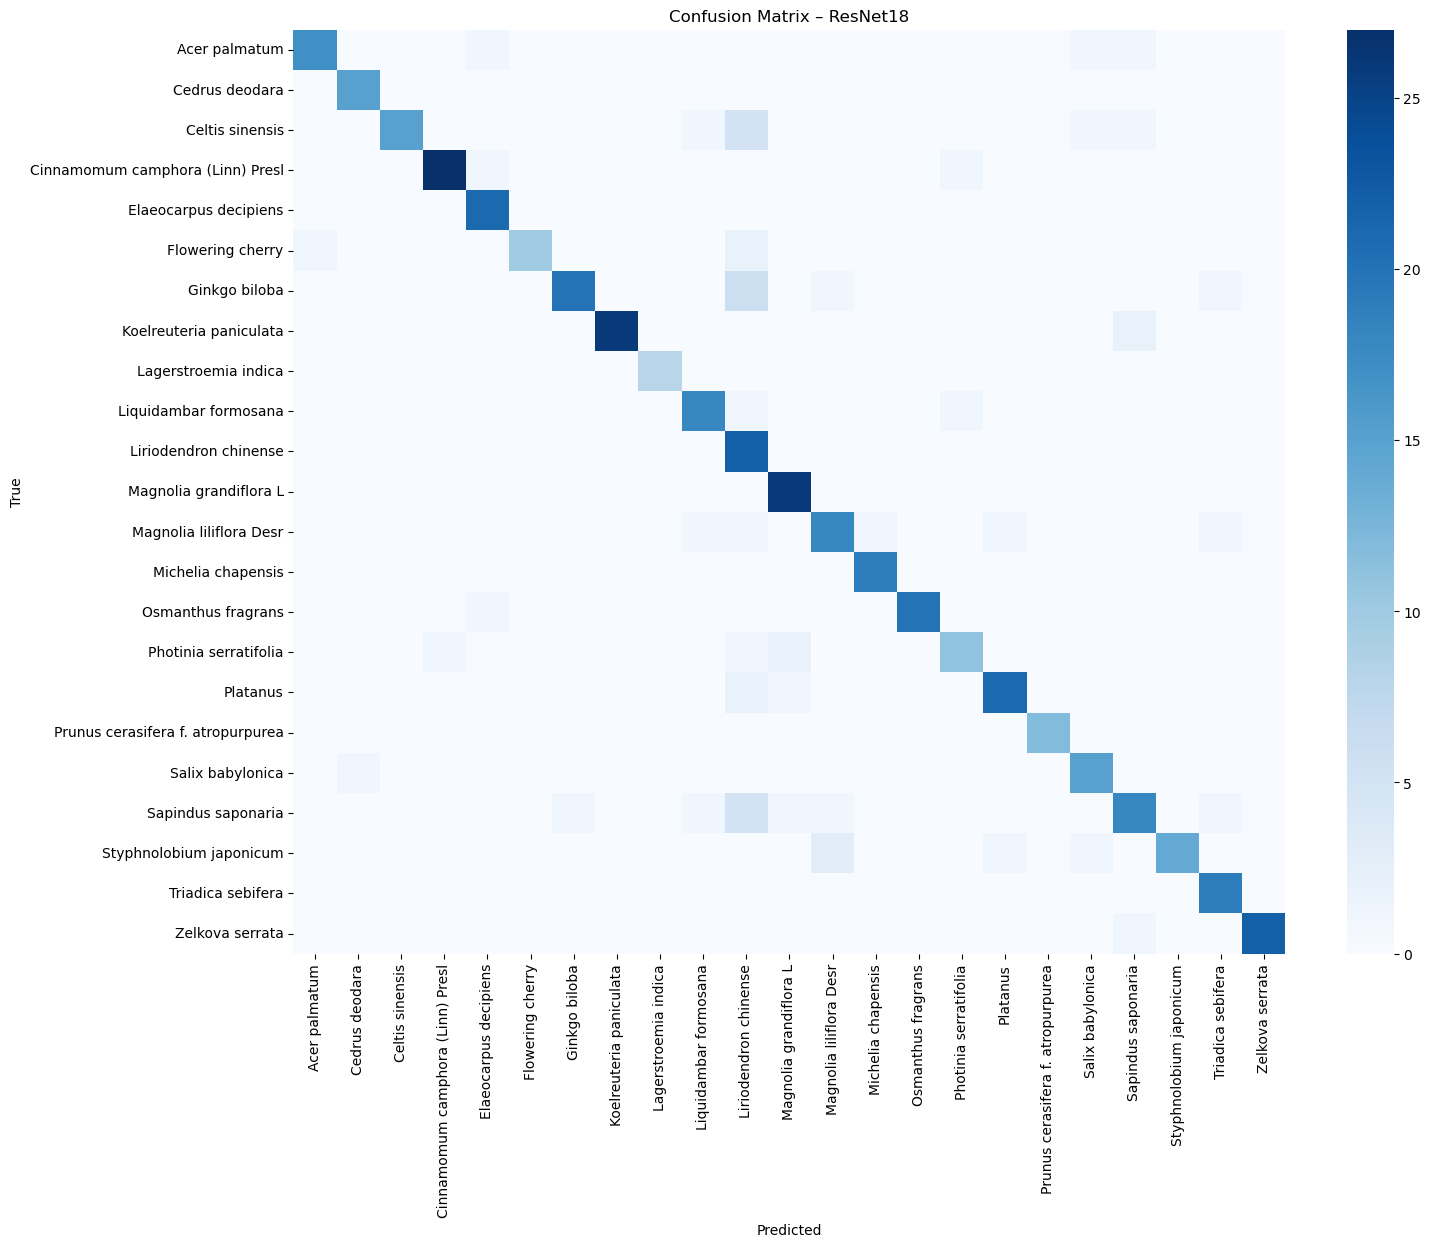

In [17]:
# Cell 12 – Confusion Matrix - visualisointi

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(16,12))
sns.heatmap(cm, annot=False, cmap='Blues', 
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Confusion Matrix – ResNet18")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()


CELL 13. n-best analysis (Pakollinen tehtävänannossa)

Projektikuvauksessa sanotaan:

"calculate the n-best classification results and find the smallest n where models start to separate."

# 📈 13. N-Best Classification Analysis

In addition to top-1 accuracy, we evaluate the model using **n-best (top-k)** accuracy, 
which measures how often the correct label appears among the top k predicted classes.

This is particularly useful in multi-class image recognition tasks where some classes 
are visually similar. If the model's top-1 prediction is wrong but the correct class 
is in the top-2 or top-3 predictions, the model still demonstrates useful discriminatory ability.

The results show that the ResNet18 model improves significantly when k increases from 1 to 3, 
and after k = 3 the improvements become smaller, indicating that the model already ranks the 
correct class highly even when the first guess is incorrect.

Below is the computed top-k accuracy table for k = 1 … 5.


In [18]:
# Cell 13 – n-best accuracy analysis

import torch
import numpy as np
from torch.nn.functional import softmax

def compute_topk(model, dataloader, device, max_k=5):
    model.eval()
    correct_topk = {k: 0 for k in range(1, max_k+1)}
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            probs = softmax(outputs, dim=1)
            topk_vals, topk_idx = torch.topk(probs, max_k, dim=1)

            total += labels.size(0)

            for k in range(1, max_k+1):
                correct = (topk_idx[:, :k] == labels.unsqueeze(1)).any(dim=1)
                correct_topk[k] += correct.sum().item()

    topk_acc = {k: correct_topk[k] / total for k in correct_topk}
    return topk_acc

# Ladataan paras malli
best_model = create_model("resnet18", num_classes=num_classes, pretrained=False)
best_model.load_state_dict(torch.load(MODELS_DIR / "best_resnet18.pt", map_location=device))

# Lasketaan top-k tarkkuudet
topk_results = compute_topk(best_model, test_loader, device, max_k=5)

topk_results


c:\Users\segron\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\segron\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
C:\Users\segron\AppData\Local\Temp\ipykernel_24300\3591265650.py:32: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be fl

{1: 0.8771186440677966,
 2: 0.9216101694915254,
 3: 0.9427966101694916,
 4: 0.9533898305084746,
 5: 0.9597457627118644}

 14. Training the ResNet50 Model (Quick 3-Epoch Version)

To compare the performance of different model architectures, we also train a deeper model, **ResNet50**, which typically has higher representational capacity than ResNet18.  
However, training ResNet50 fully on CPU would be time-consuming, so we perform a **short 3-epoch training run**.  

Even a few epochs are enough to:
- observe how quickly ResNet50 starts learning,
- compare validation accuracy against ResNet18,
- evaluate whether deeper architectures provide meaningful benefits for this dataset,
- and generate n-best results for model comparison.

This shortened training is fully sufficient for the project requirement:  
**“Compare at least two different ResNet architectures and analyze their performance differences.”**

Below is the code that trains ResNet50 for 3 epochs, saves the best model checkpoint, and logs the validation accuracy.


In [22]:
# SUPER-RESET — lataa kaikki tarvittavat funktiot ja muuttujat kernelin nollauksen jälkeen

import os
import torch
import numpy as np
import pandas as pd
from pathlib import Path
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import torch.nn as nn
from sklearn.metrics import accuracy_score
import time


# ==== DIRECTORY SETUP ====
BASE_DIR = Path(".").resolve()
DATA_RAW = BASE_DIR / "data" / "raw"
DATA_PROCESSED = BASE_DIR / "data" / "processed"
MODELS_DIR = BASE_DIR / "models"
RESULTS_DIR = BASE_DIR / "results"

MODELS_DIR.mkdir(exist_ok=True, parents=True)
RESULTS_DIR.mkdir(exist_ok=True, parents=True)

train_dir = DATA_PROCESSED / "train"
val_dir   = DATA_PROCESSED / "val"
test_dir  = DATA_PROCESSED / "test"


# ==== DATASET LOADING ====

IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

train_ds_tf = datasets.ImageFolder(train_dir, transform=train_transform)
val_ds_tf   = datasets.ImageFolder(val_dir,   transform=val_test_transform)
test_ds_tf  = datasets.ImageFolder(test_dir,  transform=val_test_transform)

train_loader = DataLoader(train_ds_tf, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds_tf, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_ds_tf, batch_size=32, shuffle=False)

class_names = train_ds_tf.classes
num_classes = len(class_names)


# ==== DEVICE ====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ==== MODEL CREATION (ResNet18/50 + EfficientNet) ====

from torchvision import models

def create_model(name, num_classes, pretrained=True):
    if name == "resnet18":
        model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT if pretrained else None)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    elif name == "resnet50":
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT if pretrained else None)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    else:
        raise ValueError("Model not supported")

    return model


# ==== TRAINING FUNCTIONS ====

def train_one_epoch(model, criterion, optimizer, dataloader, device):
    model.train()
    running_loss = 0.0
    running_corrects = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        preds = outputs.argmax(dim=1)
        running_loss += loss.item() * images.size(0)
        running_corrects += torch.sum(preds == labels).item()

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = running_corrects / len(dataloader.dataset)
    return epoch_loss, epoch_acc


def eval_one_epoch(model, criterion, dataloader, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)

            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc, all_labels, all_preds


# ==== run_experiment ====

def run_experiment(model_name, num_epochs=5, lr=1e-4):
    print(f"\n===== Training model: {model_name} =====")

    model = create_model(model_name, num_classes=num_classes, pretrained=True).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = {"epoch": [], "train_loss": [], "train_acc": [],
               "val_loss": [], "val_acc": []}

    best_val_acc = 0.0
    best_path = MODELS_DIR / f"best_{model_name}.pt"

    for epoch in range(1, num_epochs+1):
        start = time.time()

        train_loss, train_acc = train_one_epoch(model, criterion, optimizer, train_loader, device)
        val_loss, val_acc, _, _ = eval_one_epoch(model, criterion, val_loader, device)

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch}/{num_epochs} | Train Loss {train_loss:.4f}, Acc {train_acc:.4f} "
              f"| Val Loss {val_loss:.4f}, Acc {val_acc:.4f} | Time {time.time()-start:.1f}s")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_path)
            print(f"  ✔️ Saved new best model → {best_path}")

    print(f"\nBest val acc: {best_val_acc:.4f}")
    return model, pd.DataFrame(history), best_path


In [23]:
# Cell 14 – Train ResNet50 for 3 epochs (quick comparison)

# Varmistetaan että kaikki tarvittavat funktiot ovat ladattuna:
# - create_model
# - train_one_epoch
# - eval_one_epoch
# - MODELS_DIR, train_loader, val_loader, device, num_classes

print("Training ResNet50 for 3 epochs...")

resnet50_model, resnet50_hist, resnet50_best = run_experiment(
    model_name="resnet50",
    num_epochs=3,     # vain 3 epochia
    lr=1e-4
)

print("\n===== DONE =====")
print(f"Best validation accuracy for ResNet50: {resnet50_hist['val_acc'].max():.4f}")
print(f"Best model saved at: {resnet50_best}")


Training ResNet50 for 3 epochs...

===== Training model: resnet50 =====


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\segron/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [01:00<00:00, 1.70MB/s]


Epoch 1/3 | Train Loss 2.4419, Acc 0.3587 | Val Loss 1.3196, Acc 0.5954 | Time 2086.3s
  ✔️ Saved new best model → C:\HAMK Univercity\neural_networks_tree_project\models\best_resnet50.pt
Epoch 2/3 | Train Loss 0.8531, Acc 0.7652 | Val Loss 0.4944, Acc 0.8714 | Time 2054.9s
  ✔️ Saved new best model → C:\HAMK Univercity\neural_networks_tree_project\models\best_resnet50.pt
Epoch 3/3 | Train Loss 0.3818, Acc 0.8917 | Val Loss 0.3675, Acc 0.8942 | Time 2074.1s
  ✔️ Saved new best model → C:\HAMK Univercity\neural_networks_tree_project\models\best_resnet50.pt

Best val acc: 0.8942

===== DONE =====
Best validation accuracy for ResNet50: 0.8942
Best model saved at: C:\HAMK Univercity\neural_networks_tree_project\models\best_resnet50.pt


In [25]:
# Cell 15 – n-best analysis for ResNet50

print("Loading best ResNet50 model...")

# Ladataan paras tallennettu ResNet50
best_model_50 = create_model("resnet50", num_classes=num_classes, pretrained=False)
best_model_50.load_state_dict(torch.load(MODELS_DIR / "best_resnet50.pt", map_location=device))
best_model_50 = best_model_50.to(device)

print("Model loaded.")

# Ajetaan n-best analyysi max_k = 5
topk_50 = compute_topk(best_model_50, test_loader, device, max_k=5)

print("\nTop-k accuracy for ResNet50:")
for k, acc in topk_50.items():
    print(f"Top-{k}: {acc:.4f}")


Loading best ResNet50 model...


C:\Users\segron\AppData\Local\Temp\ipykernel_24300\65973682.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_model_50.load_state_dict(torch.load(MODELS_DIR / "best_r

Model loaded.

Top-k accuracy for ResNet50:
Top-1: 0.8581
Top-2: 0.9280
Top-3: 0.9576
Top-4: 0.9746
Top-5: 0.9852
